# Part 4: Model Distillation

We distill the Part-3 full-data teacher (`part3_bert_pct100`, BERT-base) into a smaller
DistilBERT student through knowledge distillation, then compare the two on accuracy and
inference speed. The student trains on the same full 64k set with the Part-3 BERT recipe;
only the distillation loss (soft teacher targets) is new.

## Setup & Environment

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q datasets==4.8.5
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Local run detected - no Colab setup needed.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Standard library imports
import json
import sys
import tempfile
from pathlib import Path

# Third-party libraries
import numpy as np
import pandas as pd


def _find_project_root(start):
    """Return the folder that contains data/processed. Walk up from `start` for local runs,
    then fall back to the Colab Drive locations (with or without the Final_submission folder)."""
    candidates = [start, *start.parents,
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT/Final_submission'),
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT')]
    for d in candidates:
        if (d / 'data' / 'processed').exists():
            return d
    raise FileNotFoundError(
        'Project root not found (no folder with data/processed). On Colab, mount Drive first '
        'and point this at the folder that holds src/, data/, and config/.')

PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.notebook_setup import bootstrap
from src.utils.evaluation import make_evaluate_model
from src.utils.guards import run_split_guard

# Load project configuration
S = bootstrap(PROJECT_ROOT)
_CFG = S.cfg
_bert = _CFG['part3']['bert']   # the student reuses the Part-3 full-data BERT recipe
_p4 = _CFG['part4']
save_fig = S.save_fig

SEED = S.SEED
CANONICAL_SEED = _CFG['canonical_seed']
IN_COLAB, RUN_TRAINING = S.IN_COLAB, S.RUN_TRAINING
N_BOOT = _CFG['eval']['n_boot']
VAL_SANITY_N = _CFG['eval']['val_sanity_n']

# Part-3 BERT recipe (shared) + Part-4 distillation knobs
STUDENT_MODEL = _p4['student_model']
TEACHER_CKPT = _p4['teacher_ckpt']
TEMPERATURE = _p4['temperature']
ALPHA = _p4['alpha']
RUN_NAME = _p4['run_name']
MAX_LENGTH = _bert['max_length']
TRAIN_BATCH = _bert['train_batch']
EVAL_BATCH = _bert['eval_batch']
LR = _bert['lr']
EPOCHS = _bert['epochs']
WARMUP_FRAC = _bert['warmup_frac']
WEIGHT_DECAY = _bert['weight_decay']
LOGGING_STEPS = _bert['logging_steps']
MAX_FINAL_TRAIN_LOSS = _bert['max_final_train_loss']

DATA_DIR, FIG_DIR, RAW_PRED_DIR = S.DATA_DIR, S.FIG_DIR, S.RAW_PRED_DIR
METRICS_DIR = S.METRICS_DIR
CKPT_DIR = Path('/content/part4_ckpt') if IN_COLAB else Path(tempfile.gettempdir()) / 'part4_ckpt'
TEACHER_DIR = RAW_PRED_DIR / TEACHER_CKPT

In [ ]:
guard = run_split_guard(DATA_DIR, expected_revision=_CFG['dataset']['revision'])
labels, classes, splits = guard['labels'], guard['classes'], guard['splits']
test_df, y_test, manifest = guard['test_df'], guard['y_test'], guard['manifest']
train_df_full = splits['train']
label2id, id2label = labels['label2id'], labels['id2label']

# Bind the frozen test set into the scoring contract (identical to notebooks 00/03).
evaluate_model = make_evaluate_model(test_df=test_df, y_test=y_test, classes=classes,
                                     fig_dir=FIG_DIR, n_boot=N_BOOT, seed=SEED)

Split guard OK - test fingerprint 0da3f09e8a2b... matches the manifest.
Frozen splits: 64,069 train / 16,018 val / 20,022 test  -  dataset revision 186902250e94...


## 4.a Knowledge Distillation

The student learns from the teacher's full softened probability distribution, not just the
hard label. The loss is `alpha * KD + (1 - alpha) * cross-entropy`, where the KD term is the
KL divergence between temperature-softened student and teacher logits (temperature
`2.0`, alpha `0.7`). The teacher is frozen. Training runs on the Colab GPU through
`train_distilled` (in `src/models/distillation.py`), then scores the test predictions through the
shared `evaluate_model` contract in the same pass, writing the metrics and per-example
predictions to `results/` on Drive and stages raw test predictions to
`results/colab_runs/`. Scoring is local, so this notebook runs end to end off the staged CSV.

part4_student_distill: 64,069 rows -> 6,009 optimizer steps (600 warmup)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

part4_student_distill: 7/7 classes predicted on the val sanity sample


Map:   0%|          | 0/20022 [00:00<?, ? examples/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

part4_student_distill: final model + training config saved to /content/drive/MyDrive/BSE/NLP-PROJECT/Final_submission/results/colab_runs/part4_student_distill_model
run_name                                               part4_student_distill
seed                                                                      42
n_train_rows                                                           64069
total_steps                                                             6009
warmup_steps                                                             600
final_loss                                                          0.133991
val_class_spread                                                           7
teacher_dir                /content/drive/MyDrive/BSE/NLP-PROJECT/Final_s...
student_model                                        distilbert-base-uncased
temperature                                                              2.0
alpha                                                            

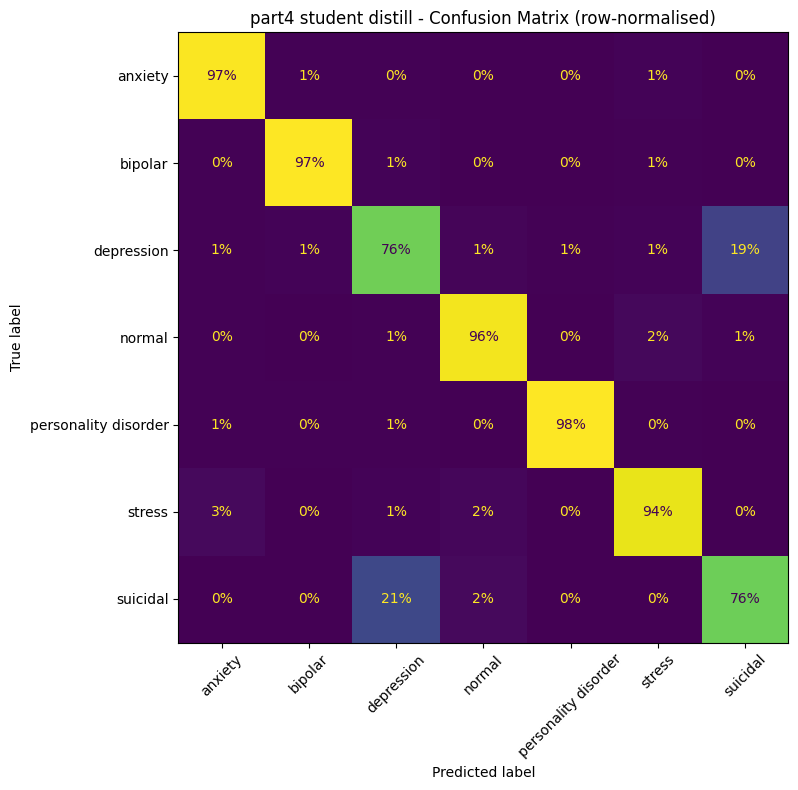


Re-run notebooks/00_evaluation.ipynb top to bottom to refresh the ladder.


In [ ]:
if not RUN_TRAINING:
    print('RUN_TRAINING is False - distillation and scoring run on the Colab GPU. Skipping.')
else:
    from src.models.distillation import train_distilled

    val_sanity_df = splits['val'].sample(n=VAL_SANITY_N, random_state=SEED)
    # Skip only if a real trained student model exists; a stale predictions CSV alone retrains.
    if (RAW_PRED_DIR / f'{RUN_NAME}_model' / 'config.json').exists():
        print(f'{RUN_NAME}_model exists - skipping training, re-scoring below.')
    else:
        summary = train_distilled(
            train_df_full, RUN_NAME, str(TEACHER_DIR), CANONICAL_SEED,
            classes=classes, id2label=id2label, label2id=label2id,
            test_df=test_df, val_sanity_df=val_sanity_df,
            raw_pred_dir=RAW_PRED_DIR, ckpt_dir=CKPT_DIR,
            student_model_name=STUDENT_MODEL, max_length=MAX_LENGTH,
            train_batch=TRAIN_BATCH, eval_batch=EVAL_BATCH, lr=LR, epochs=EPOCHS,
            warmup_frac=WARMUP_FRAC, weight_decay=WEIGHT_DECAY, logging_steps=LOGGING_STEPS,
            temperature=TEMPERATURE, alpha=ALPHA,
            save_checkpoint_as=f'{RUN_NAME}_model')
        print(pd.Series({k: v for k, v in summary.items() if k != 'loss_history'}).to_string())

    # Score on Colab through the shared contract: writes results/metrics/{RUN_NAME}.json and the
    # per-example predictions to Drive, so the student lands in the notebook 00 ladder.
    run = json.loads((RAW_PRED_DIR / f'{RUN_NAME}.json').read_text())
    if run.get('final_loss') is not None and not run['final_loss'] < MAX_FINAL_TRAIN_LOSS:
        print(f"WARNING: final train loss {run['final_loss']} >= {MAX_FINAL_TRAIN_LOSS} - investigate.")

    preds = pd.read_csv(RAW_PRED_DIR / f'{RUN_NAME}.csv', index_col='test_id')
    assert preds.index.equals(test_df.index), f'{RUN_NAME}.csv is not aligned with the frozen test index.'

    extras = {'teacher': 'part3_bert_pct100', 'student_model': STUDENT_MODEL,
              'temperature': TEMPERATURE, 'alpha': ALPHA,
              'canonical_seed': CANONICAL_SEED, 'single_seed_disclosed': True,
              'seed_runs': {str(CANONICAL_SEED): run}}
    for k in ('teacher_parameters', 'student_parameters', 'parameter_reduction_pct'):
        if k in run:
            extras[k] = run[k]

    m = evaluate_model(RUN_NAME, preds['y_pred'].to_numpy(), extras=extras)
    print('\nRe-run notebooks/00_evaluation.ipynb top to bottom to refresh the ladder.')

These results show that the training loss decreased steadily from approximately 4.52 at the beginning of training to 0.13 at the final step, indicating successful convergence of the student model.

Furthermore, predictions on the validation sanity sample covered all seven target classes, suggesting that the distilled model preserved the ability to distinguish between the complete set of mental-health categories.

Although performance remained high after distillation, the confusion matrix shows that errors are concentrated almost exclusively between the depression and suicidal categories. Approximately one-fifth of suicidal posts are classified as depression and vice versa, whereas confusion among the remaining classes is minimal. This suggests that the distilled model retains the ability to distinguish broad mental-health conditions while losing some of the precise semantic representations required to separate closely related categories. The pattern is consistent with the observed reduction in suicidal recall and indicates that performance degradation is concentrated in the most challenging classification boundary rather than being distributed uniformly across all classes.

## 4.b Performance and Speed Comparison

Read the teacher and student metrics back from the harness and compare. Parameter counts come
from the staged run record, so no model has to be loaded for the table.

In [ ]:
teacher_metrics = json.loads((METRICS_DIR / 'part3_bert_pct100.json').read_text())
student_metrics = json.loads((METRICS_DIR / f'{RUN_NAME}.json').read_text())

# Both parameter counts are recorded on the student run (teacher_parameters / student_parameters).
tp = student_metrics.get('teacher_parameters')
sp = student_metrics.get('student_parameters')

def _row(m, params):
    return {'accuracy': m['accuracy'], 'macro_f1': m['macro_f1'], 'kappa': m['kappa'],
            'suicidal_recall': m['per_class']['suicidal']['recall'], 'parameters': params}

cmp = pd.DataFrame({'Teacher (BERT-base)': _row(teacher_metrics, tp),
                    'Student (DistilBERT)': _row(student_metrics, sp)}).T
print(cmp.round(4).to_string())

if tp and sp:
    print(f'\nParameter reduction: {(1 - sp / tp) * 100:.1f}%  ({tp:,} -> {sp:,})')
acc_drop = (teacher_metrics['accuracy'] - student_metrics['accuracy']) * 100
print(f'Accuracy change: {acc_drop:+.2f} points  '
      f"({teacher_metrics['accuracy']:.4f} -> {student_metrics['accuracy']:.4f})")

                      accuracy  macro_f1   kappa  suicidal_recall   parameters
Teacher (BERT-base)     0.9172    0.9108  0.9031           0.7840  109487623.0
Student (DistilBERT)    0.9134    0.9068  0.8987           0.7618   66958855.0

Parameter reduction: 38.8%  (109,487,623 -> 66,958,855)
Accuracy change: +0.37 points  (0.9172 -> 0.9134)


When comparing the teacher and student models, the distillation process resulted in small decreases across all evaluation metrics. However, these reductions were minimal, meaning that the student model successfully retained most of the knowledge learned by the teacher. The largest decrease was observed in suicidal recall. This reduction may be related to the class imbalance present in the dataset, as minority classes are typically more difficult for smaller models to represent accurately.

Moreover, knowledge distillation reduced the number of model parameters from 109.5 million to 67 million, corresponding to a 38.84% reduction in parameter count.

These results demonstrate the effectiveness of knowledge distillation as a model compression technique. While there is a trade-off between efficiency and predictive performance, the distilled DistilBERT model preserves nearly the same classification quality as the original BERT-base model while requiring fewer parameters. This suggests that the student model is a practical alternative for deployment in environments with limitations in computational resources or memory usage.

### Inference speed

Wall-clock latency on a fixed test subset, teacher versus student. This loads both models, so
it runs only on the GPU path (Colab).

In [ ]:
STUDENT_DIR = RAW_PRED_DIR / f'{RUN_NAME}_model'
if not RUN_TRAINING:
    print('RUN_TRAINING is False - the speed benchmark needs both models on the GPU. Run on Colab.')
elif not (STUDENT_DIR / 'config.json').exists():
    print(f'{STUDENT_DIR.name} not found - the student model is only saved on a fresh train. '
          f'Delete results/colab_runs/{RUN_NAME}.csv and re-run to retrain, then benchmark.')
else:
    import time
    import torch
    from datasets import Dataset
    from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                              DataCollatorWithPadding, Trainer)

    tok = AutoTokenizer.from_pretrained(str(TEACHER_DIR))
    collator = DataCollatorWithPadding(tokenizer=tok)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    N_SPEED = 1000
    sub = test_df.iloc[:N_SPEED]
    ds = Dataset.from_pandas(sub.reset_index(drop=True)).map(
        lambda b: tok(b['text'], truncation=True, max_length=MAX_LENGTH),
        batched=True, remove_columns=['text', 'status'])

    rows = []
    for label, model_dir in [('Teacher (BERT-base)', TEACHER_DIR), ('Student (DistilBERT)', STUDENT_DIR)]:
        model = AutoModelForSequenceClassification.from_pretrained(str(model_dir)).to(device).eval()
        ds_m = ds.remove_columns(['token_type_ids']) if 'token_type_ids' in ds.column_names \
            and 'distilbert' in str(model_dir).lower() else ds
        t = time.perf_counter()
        Trainer(model=model, data_collator=collator).predict(ds_m)
        dt = time.perf_counter() - t
        rows.append({'Model': label, 'total_s': dt, 'ms_per_sample': dt / len(ds_m) * 1000})
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    speed = pd.DataFrame(rows).set_index('Model')
    print(speed.round(4).to_string())
    print(f"\nStudent is {speed.loc['Teacher (BERT-base)', 'total_s'] / speed.loc['Student (DistilBERT)', 'total_s']:.2f}x faster.")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

                      total_s  ms_per_sample
Model                                       
Teacher (BERT-base)    3.2609         3.2609
Student (DistilBERT)   1.7691         1.7691

Student is 1.84x faster.


This inference speed benchmark shows that the distilled DistilBERT model is considerably faster than the original BERT-base model. This result is consistent with the parameter reduction observed in the previous section, as the smaller architecture enables the student model to achieve a **1.84x speedup** while maintaining performance very close to that of the teacher model.

As in the previous comparison, these results demonstrate that knowledge distillation provides a favorable trade-off between computational efficiency and predictive quality, making the distilled model a suitable option for deployment in resource-constrained environments.

*This benchmark was performed using GPU acceleration and therefore the inference speed and the speedup must be interpreted according to the hardware configuration.*

## 4.c Analysis and Conclusion

The results from the reduction in model complexity show that there are substantial gains in parameter efficiency and inference speed with only minimal decreases in classification performance.

Although the distilled DistilBERT model preserved most of the teacher model's predictive performance, small decreases were observed across all evaluation metrics, with the largest reduction occurring in suicidal recall. This suggests that some more fine knowledge learned by the larger BERT model was not fully transferred during distillation. Since DistilBERT contains fewer transformer layers and parameters, it has a lower representational capacity, which may limit its ability to capture subtle contextual patterns in challenging classes,such as the suicidal and depression classes.

However, this performance gap is unlikely to be caused by training instability, as the validation loss decreased consistently throughout all training epochs. Therefore, these observed differences are more likely a consequence of model compression rather than ineffective optimization. In addition, previous analysis showed that the depression and suicidal classes contain a higher proportion of posts exceeding the 512 token limit, which makes them more sensitive to information loss caused by sequence truncation and model compression.

Several improvements could be explored in future work. First, hyperparameter tuning of the distillation process, particularly the temperature and loss weighting factor (α), may improve knowledge transfer. Second, techniques such as class-weighted losses or data augmentation could help mitigate the effects of class imbalance and improve performance on underrepresented classes. Finally, more advanced compression approaches, including progressive distillation or quantization, could be investigated to further reduce computational requirements while preserving predictive performance.